# How to Run This Notebook

To successfully run this notebook:

- Execute all cells **sequentially from top to bottom**
- Ensure the following files are present in the root directory:
  - `DvXray_Positive_Samples.zip`
  - `DvXray_Negative_Samples.zip`
  - `helper_functions.py`

- The helper functions used in this project are located in the `resnet` folder of the repository

- This project was developed and tested using **Google Colab**, so it is recommended to run the notebook in a Colab environment for compatibility

# Project Overview

This project focuses on **anomaly detection using deep learning**. The goal is to train a model that can distinguish between normal and abnormal samples in an imbalanced dataset.

We implemented a **ResNet-based architecture using PyTorch**, trained it from scratch, and evaluated its performance using appropriate metrics.

This notebook contains:
- Data loading and preprocessing
- Model architecture definition
- Training and validation pipeline
- Performance evaluation
- Model saving and reproducibility steps

### Dataset Setup

The project uses three required files placed in the root directory:
- `DvXray_Positive_Samples.zip`
- `DvXray_Negative_Samples.zip`
- `helper_functions.py`

These files must reside in the same directory as the notebook.  
The code automatically handles:
- Extraction of image data
- Loading of positive and negative samples
- Preprocessing and dataset construction



In [ ]:
import os
print(os.listdir("/content"))

In [3]:
import zipfile

with zipfile.ZipFile("/content/DvXray_Positive_Samples.zip", 'r') as z:
    z.extractall("/content")

with zipfile.ZipFile("/content/DvXray_Negative_Samples.zip", 'r') as z:
    z.extractall("/content")

Imports and CUDA


In [4]:
# Torch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
import random
import json
import os
from helper_functions import *

In [5]:
# Use GPU if available, else use CPU
device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available()
                      else "cpu")
print(device)

cuda


DvXray Dataset

A large-scale dual-view X-ray baggage dataset for prohibited item detection.

    Views: Overlook (OL) & Side (SD) X-ray images
    15 threat classes: Gun, Knife, Hammer, Battery, etc.
    Negative samples: Benign baggage
    Annotations: JSON with bounding boxes


In [6]:
# DvXray Dataset
class DvXrayDataset(Dataset):
    """DvXray Dataset: dual-view X-ray baggage dataset for prohibited item detection.

    Args:
        transform: Optional transform to apply to each image.
        download: If True, downloads the dataset from Google Drive if not found.
    """

    def __init__(self, transform=None, download=False):
        # Download if requested
        if download and not check_dvxray_exists():
            download_and_extract_dvxray("/content")
        neg_dir, pos_dir = get_directories()

        # Read dataset from directories
        self.samples = []
        self.labels = {}  # cache: ol_path -> list of label strings
        self.transform = transform

        # Add negative images into dataset
        for fname in os.listdir(neg_dir):
            if fname.endswith('_OL.png'):
                base = fname.replace('_OL.png', '')
                ol = os.path.join(neg_dir, base + '_OL.png')
                sd = os.path.join(neg_dir, base + '_SD.png')
                if os.path.exists(sd):
                    self.samples.append((ol, sd, 0))    # negatives = 0
                    self.labels[ol] = ["Benign"]
                else:
                    print(f"Missing SD for negative: {base}")

        # Add positive images into dataset
        for fname in os.listdir(pos_dir):
            if fname.endswith('_OL.png'):
                base = fname.replace('_OL.png', '')
                ol = os.path.join(pos_dir, base + '_OL.png')
                sd = os.path.join(pos_dir, base + '_SD.png')
                if os.path.exists(sd):
                    self.samples.append((ol, sd, 1))    # positives = 1
                    json_path = os.path.join(pos_dir, base + '.json')
                    obj_labels = []
                    if os.path.exists(json_path):
                        with open(json_path) as f:
                            data = json.load(f)
                        objects = data.get("objects")
                        if isinstance(objects, list) and len(objects) > 0:
                            for obj in objects:
                                obj_labels.append(obj["label"])
                        else:
                            obj_labels = ["Benign"]
                    else:
                        obj_labels = ["Benign"]
                    self.labels[ol] = obj_labels
                else:
                    print(f"Missing SD for positive: {base}")

        # Build label_map: Benign=0, threat classes sorted from 1
        all_labels = set()
        for label_list in self.labels.values():
            all_labels.update(label_list)

        self.label_map = {"Benign": 0}
        self.label_map.update(
            {label: i + 1 for i, label in enumerate(sorted(all_labels - {"Benign"}))}
        )
        self.num_classes = len(self.label_map)

    def __getitem__(self, idx):
        """Returns (image, vector, binary)"""
        ol_path, sd_path, binary_label = self.samples[idx]
        ol = Image.open(ol_path).convert('RGB')
        sd = Image.open(sd_path).convert('RGB')
        if self.transform:
            ol = self.transform(ol)
            sd = self.transform(sd)

        # image = torch.cat([ol, sd], dim=0)
        image = (ol + sd) / 2
        multi_hot = torch.zeros(self.num_classes)
        for label_str in self.labels[ol_path]:
            if label_str in self.label_map:
                multi_hot[self.label_map[label_str]] = 1.0

        # (6 channel 128 x 128 image, vector of length num_classes, label)
        return image, multi_hot, binary_label

    def __len__(self):
        """Return sample count"""
        return len(self.samples)

    def __repr__(self):
        """Return string representation of dataset"""
        pos_count = sum(1 for _, _, binary_label in self.samples if binary_label == 1)
        neg_count = len(self.samples) - pos_count
        return (f"DvXrayDataset(samples={len(self.samples)}, pos={pos_count}, neg={neg_count}, "
                f"classes={self.num_classes})\n"
                f"Labels: {', '.join(f'{v}:{k}' for k, v in self.label_map.items())}")

In [7]:
import os
print(os.listdir("/content"))

['.config', 'DvXray_Positive_Samples', 'DvXray_Negative_Samples.zip', 'DvXray_Negative_Samples', '__pycache__', 'helper_functions.py', 'DvXray_Positive_Samples.zip', 'sample_data']


In [8]:
# Default transform: resize, tensor conversion, and normalization
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

# Load the data (downloads if not present)
dataset = DvXrayDataset(transform=transform, download=False)
print(dataset)

DvXrayDataset(samples=16000, pos=5000, neg=11000, classes=16)
Labels: 0:Benign, 1:Bat, 2:Battery, 3:Dart, 4:Fireworks, 5:Gun, 6:Hammer, 7:Knife, 8:Lighter, 9:Pliers, 10:Pressure_vessel, 11:Razor_blade, 12:Saw_blade, 13:Scissors, 14:Screwdriver, 15:Wrench


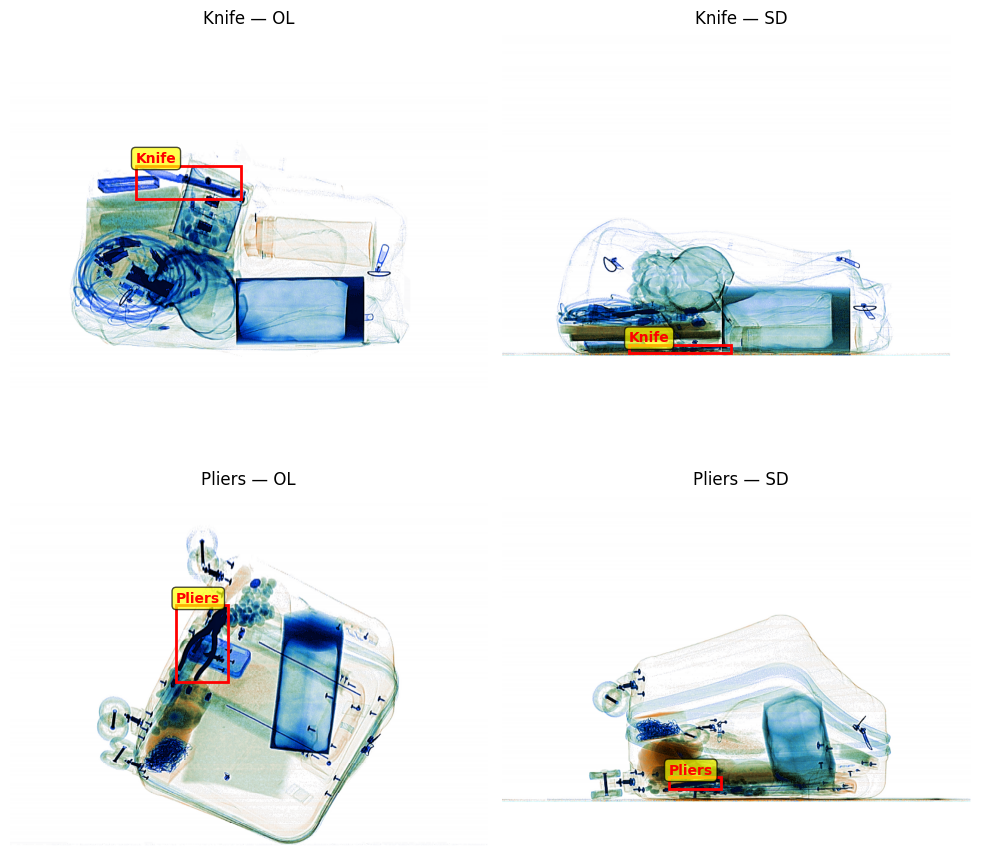

In [ ]:
# # Show first 2 classes
# visualize_samples(dataset, n_classes=2)

# Dataset and Problem Definition

This task is framed as an **anomaly detection problem**, where:
- The dataset is **imbalanced**
- Majority class = Normal
- Minority class = Anomalous (target of interest)

Inputs:
- Images from the dataset

Outputs:
- Predicted class (normal vs anomaly / multi-class depending on setup)

We follow best practices:
- Train / Validation / Test split
- Evaluation on unseen test data

### Data Splitting

The dataset is split into:
- 80% Training set
- 10% Validation set
- 10% Test set

A fixed random seed is used to ensure reproducibility.  
This guarantees that the same samples are used across runs.

The `random_split` function is used with a seeded generator to ensure consistent dataset partitioning.

In [9]:
import torchvision.models as models

import torch
import numpy as np
import random

seed = 42

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [10]:
from torch.utils.data import random_split

total_size = len(dataset)

generator = torch.Generator().manual_seed(seed)

train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size], generator=generator
)

print(len(train_dataset), len(val_dataset), len(test_dataset))

12800 1600 1600


### Data Loading

PyTorch `DataLoader` is used to efficiently load data in batches.

- Training data is shuffled to improve generalization.
- Validation and test data are not shuffled to ensure consistent evaluation.

Batch size is set to 32 for a balance between speed and memory usage.

In [11]:
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=2, pin_memory=True)

val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                        num_workers=2, pin_memory=True)

test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                         num_workers=2, pin_memory=True)

# Data Loading and Preprocessing

In this section, we:
- Load the dataset from the specified directory
- Apply transformations such as resizing, normalization, and augmentation
- Create PyTorch DataLoaders for efficient batching

Why this is important:
- Ensures consistent input format for the model
- Improves generalization via data augmentation
- Enables efficient GPU training

In [12]:
import torchvision.models as models
import torch.nn as nn

class ResNetDual(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.base = models.resnet18(pretrained=True)

        in_features = self.base.fc.in_features
        self.base.fc = nn.Identity()

        # TWO OUTPUTS
        self.multi_head = nn.Linear(in_features, num_classes)
        self.binary_head = nn.Linear(in_features, 2)

    def forward(self, x):
        features = self.base(x)
        multi_out = self.multi_head(features)     # object class
        binary_out = self.binary_head(features)   # threat / no threat
        return multi_out, binary_out

# Model Architecture

We use a **ResNet18-based model** as the backbone.

Key design choices:
- ResNet18 for feature extraction
- Replace the final fully connected layer
- Add custom classification heads:
  - Multi-class classification head
  - Binary classification head (anomaly detection)

Why this design:
- ResNet captures strong visual features
- Dual-head allows the model to perform both classification tasks simultaneously

# Class Imbalance Handling (Class Weighting)

To address class imbalance, class-weighted loss can be used to assign higher importance to minority classes during training.

This helps reduce bias toward dominant classes and improves performance on underrepresented categories, especially in the multi-class classification task.

In [13]:
import torch
model = ResNetDual(dataset.num_classes).to(device)


# ===== CLASS WEIGHTS (ADD HERE) =====
import torch

class_counts = torch.tensor([
    1083, 31, 31, 33, 44, 41, 34, 33,
    39, 36, 34, 31, 31, 34, 32, 33
], dtype=torch.float)

weights = 1.0 / class_counts
weights = weights / weights.sum()
weights = weights.to(device)

# ===== LOSS FUNCTIONS =====
criterion_multi = nn.BCEWithLogitsLoss(pos_weight=weights) # new and updated


# criterion_multi = nn.BCEWithLogitsLoss()   # for multi-label
criterion_binary = nn.CrossEntropyLoss()   # for binary

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 239MB/s]


In [14]:
import os
import datetime

run_name = "resnetwoptimizationseed"
save_dir = f"/content/runs{run_name}"
os.makedirs(save_dir, exist_ok=True)

print("Saving to:", save_dir)

Saving to: /content/runsresnetwoptimizationseed


# Forward Pass

The forward pass works as follows:
1. Input image is passed through the ResNet backbone
2. Feature vector is extracted
3. Features are fed into:
   - Multi-class output layer (16 classes)
   - Binary classification layer

Outputs:
- Multi-class prediction (object category)
- Binary prediction (anomaly vs normal)

In [15]:
results = {
    "phase1": {
        "train_multi": [], "train_binary": [],
        "val_multi": [], "val_binary": [],
        "val_loss": [], "val_acc": []
    },
    "phase2": {
        "train_multi": [], "train_binary": [],
        "val_multi": [], "val_binary": [],
        "val_loss": [], "val_acc": []
    },
    "phase3": {
        "train_multi": [], "train_binary": [],
        "val_multi": [], "val_binary": [],
        "val_loss": [], "val_acc": []
    },
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

epochs = 20

def train_model(model, train_loader, val_loader, optimizer, scheduler, epochs, phase):

    for epoch in range(epochs):

        # ================= TRAIN =================
        model.train()
        total_loss = 0
        total_multi = 0
        total_binary = 0

        for images, multi_labels, binary_labels in train_loader:
            images = images.to(device)
            multi_labels = multi_labels.to(device)
            binary_labels = binary_labels.long().to(device)

            multi_out, binary_out = model(images)

            loss_multi = criterion_multi(multi_out, multi_labels)
            loss_binary = criterion_binary(binary_out, binary_labels)

            loss = loss_multi + loss_binary

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_multi += loss_multi.item()
            total_binary += loss_binary.item()

        avg_loss = total_loss / len(train_loader)
        results[phase]["train_multi"].append(total_multi / len(train_loader))
        results[phase]["train_binary"].append(total_binary / len(train_loader))

        # ================= VALIDATION =================
        model.eval()
        val_loss = 0
        val_multi = 0
        val_binary = 0

        correct = 0     # NEW (accuracy)
        total = 0

        with torch.no_grad():
            for images, multi_labels, binary_labels in val_loader:
                images = images.to(device)
                multi_labels = multi_labels.to(device)
                binary_labels = binary_labels.long().to(device)

                multi_out, binary_out = model(images)

                loss_multi = criterion_multi(multi_out, multi_labels)
                loss_binary = criterion_binary(binary_out, binary_labels)

                val_loss += (loss_multi + loss_binary).item()
                val_multi += loss_multi.item()
                val_binary += loss_binary.item()

                # ACCURACY (multiclass)

                preds = multi_out.argmax(dim=1)
                labels_idx = multi_labels.argmax(dim=1)

                correct += (preds == labels_idx).sum().item()
                total += multi_labels.size(0)

        val_loss /= len(val_loader)
        val_acc = correct / total

        results[phase]["val_multi"].append(val_multi / len(val_loader))
        results[phase]["val_binary"].append(val_binary / len(val_loader))

        print(f"{phase} Epoch {epoch+1}: Train {avg_loss:.4f}, Val {val_loss:.4f}, Acc {val_acc:.4f}")

        # STORE
        results[phase]["val_loss"].append(val_loss)
        results[phase]["val_acc"].append(val_acc)

        # FIXED POSITION (AFTER validation)
        scheduler.step()


# Phased Training Strategy

The model is trained using a three-phase training strategy to progressively refine performance:

- Phase 1: Train the full model to learn general feature representations
- Phase 2: Freeze most of the backbone and train only higher-level layers (e.g., layer4) for task-specific refinement
- Phase 3: Partially unfreeze deeper layers (layer3 and layer4) and fine-tune the model jointly

This staged approach stabilizes training, improves convergence, and helps balance learning between the binary and multi-class tasks.

In [16]:
for param in model.base.parameters():
    param.requires_grad = False

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.1)

train_model(model, train_loader, val_loader, optimizer, scheduler, epochs, "phase1")

phase1 Epoch 1: Train 0.3312, Val 0.2481, Acc 0.6562
phase1 Epoch 2: Train 0.2598, Val 0.2124, Acc 0.6606
phase1 Epoch 3: Train 0.2450, Val 0.2098, Acc 0.6538
phase1 Epoch 4: Train 0.2427, Val 0.2121, Acc 0.6594
phase1 Epoch 5: Train 0.2457, Val 0.2086, Acc 0.6594
phase1 Epoch 6: Train 0.2402, Val 0.2099, Acc 0.6613
phase1 Epoch 7: Train 0.2357, Val 0.2057, Acc 0.6644
phase1 Epoch 8: Train 0.2336, Val 0.2091, Acc 0.6637
phase1 Epoch 9: Train 0.2406, Val 0.2158, Acc 0.6550
phase1 Epoch 10: Train 0.2376, Val 0.2072, Acc 0.6637
phase1 Epoch 11: Train 0.2398, Val 0.2079, Acc 0.6644
phase1 Epoch 12: Train 0.2386, Val 0.2084, Acc 0.6600
phase1 Epoch 13: Train 0.2429, Val 0.2078, Acc 0.6675
phase1 Epoch 14: Train 0.2390, Val 0.2083, Acc 0.6613
phase1 Epoch 15: Train 0.2388, Val 0.2084, Acc 0.6625
phase1 Epoch 16: Train 0.2383, Val 0.2088, Acc 0.6631
phase1 Epoch 17: Train 0.2368, Val 0.2081, Acc 0.6637
phase1 Epoch 18: Train 0.2372, Val 0.2083, Acc 0.6637
phase1 Epoch 19: Train 0.2401, Val 0.

In [17]:
for param in model.base.parameters():
    param.requires_grad = False   # RESET FIRST

for name, param in model.base.named_parameters():
    if "layer4" in name:
        param.requires_grad = True

optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.1)

train_model(model, train_loader, val_loader, optimizer, scheduler, epochs, "phase2")

phase2 Epoch 1: Train 0.1570, Val 0.0916, Acc 0.7312
phase2 Epoch 2: Train 0.0641, Val 0.1161, Acc 0.7288
phase2 Epoch 3: Train 0.0267, Val 0.0948, Acc 0.7375
phase2 Epoch 4: Train 0.0186, Val 0.0944, Acc 0.7456
phase2 Epoch 5: Train 0.0167, Val 0.0964, Acc 0.7444
phase2 Epoch 6: Train 0.0159, Val 0.0984, Acc 0.7400
phase2 Epoch 7: Train 0.0152, Val 0.0957, Acc 0.7431
phase2 Epoch 8: Train 0.0155, Val 0.0938, Acc 0.7425
phase2 Epoch 9: Train 0.0156, Val 0.0934, Acc 0.7475
phase2 Epoch 10: Train 0.0158, Val 0.0969, Acc 0.7438
phase2 Epoch 11: Train 0.0156, Val 0.0949, Acc 0.7488
phase2 Epoch 12: Train 0.0156, Val 0.0983, Acc 0.7438
phase2 Epoch 13: Train 0.0150, Val 0.0944, Acc 0.7456
phase2 Epoch 14: Train 0.0154, Val 0.0937, Acc 0.7456
phase2 Epoch 15: Train 0.0161, Val 0.0979, Acc 0.7444
phase2 Epoch 16: Train 0.0144, Val 0.0927, Acc 0.7494
phase2 Epoch 17: Train 0.0149, Val 0.0975, Acc 0.7450
phase2 Epoch 18: Train 0.0147, Val 0.0939, Acc 0.7494
phase2 Epoch 19: Train 0.0150, Val 0.

In [18]:
for param in model.base.parameters():
    param.requires_grad = False

for name, param in model.base.named_parameters():
    if "layer3" in name or "layer4" in name:
        param.requires_grad = True

optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.1)

train_model(model, train_loader, val_loader, optimizer, scheduler, epochs, "phase3")

phase3 Epoch 1: Train 0.0157, Val 0.1065, Acc 0.7425
phase3 Epoch 2: Train 0.0120, Val 0.0984, Acc 0.7506
phase3 Epoch 3: Train 0.0104, Val 0.0995, Acc 0.7456
phase3 Epoch 4: Train 0.0105, Val 0.1020, Acc 0.7462
phase3 Epoch 5: Train 0.0106, Val 0.1063, Acc 0.7475
phase3 Epoch 6: Train 0.0100, Val 0.1022, Acc 0.7475
phase3 Epoch 7: Train 0.0101, Val 0.1031, Acc 0.7469
phase3 Epoch 8: Train 0.0102, Val 0.0994, Acc 0.7469
phase3 Epoch 9: Train 0.0100, Val 0.0979, Acc 0.7494
phase3 Epoch 10: Train 0.0099, Val 0.1012, Acc 0.7494
phase3 Epoch 11: Train 0.0098, Val 0.0993, Acc 0.7469
phase3 Epoch 12: Train 0.0100, Val 0.1039, Acc 0.7469
phase3 Epoch 13: Train 0.0101, Val 0.1019, Acc 0.7481
phase3 Epoch 14: Train 0.0101, Val 0.1021, Acc 0.7475
phase3 Epoch 15: Train 0.0100, Val 0.1039, Acc 0.7475
phase3 Epoch 16: Train 0.0100, Val 0.1053, Acc 0.7475
phase3 Epoch 17: Train 0.0111, Val 0.0957, Acc 0.7488
phase3 Epoch 18: Train 0.0099, Val 0.1029, Acc 0.7481
phase3 Epoch 19: Train 0.0105, Val 0.

In [19]:

torch.save(model.state_dict(), f"{save_dir}/resnet.pth")

import json
with open(f"{save_dir}/metrics.json", "w") as f:
    json.dump(results, f)


# Evaluation Metrics

We evaluate the model using:
- Validation Accuracy per epoch per phase
- Validation Loss per epoch per phase

For anomaly detection, these metrics help determine:
- How well the model detects rare abnormal cases
- Whether the model is biased toward the majority class

Evaluation is done on:
- Test set (final performance) to find precision, recall, f1 score and support

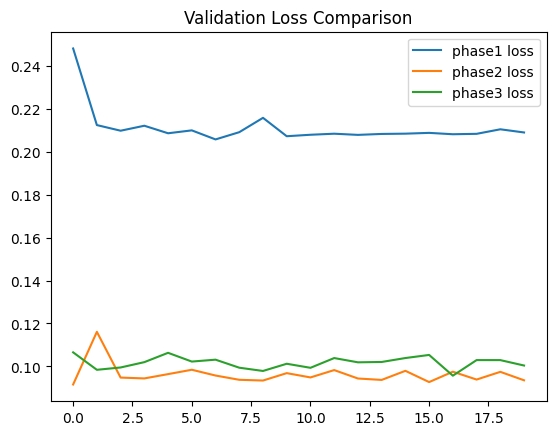

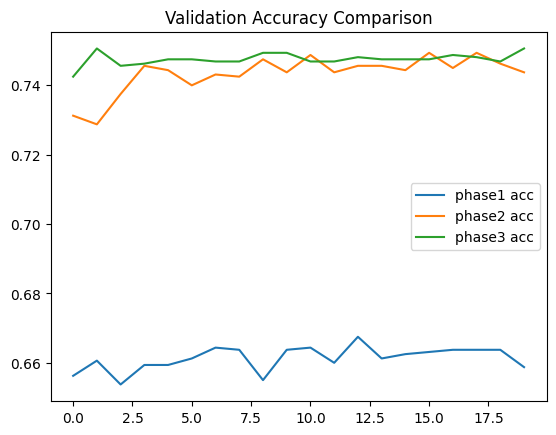

In [20]:
import matplotlib.pyplot as plt

for phase in results:
    plt.plot(results[phase]["val_loss"], label=f"{phase} loss")

plt.legend()
plt.title("Validation Loss Comparison")
plt.show()


for phase in results:
    plt.plot(results[phase]["val_acc"], label=f"{phase} acc")

plt.legend()
plt.title("Validation Accuracy Comparison")
plt.show()

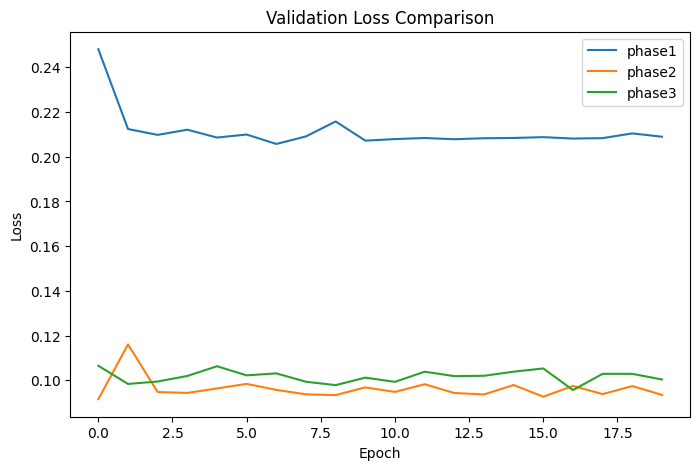

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
for phase in results:
    plt.plot(results[phase]["val_loss"], label=phase)

plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

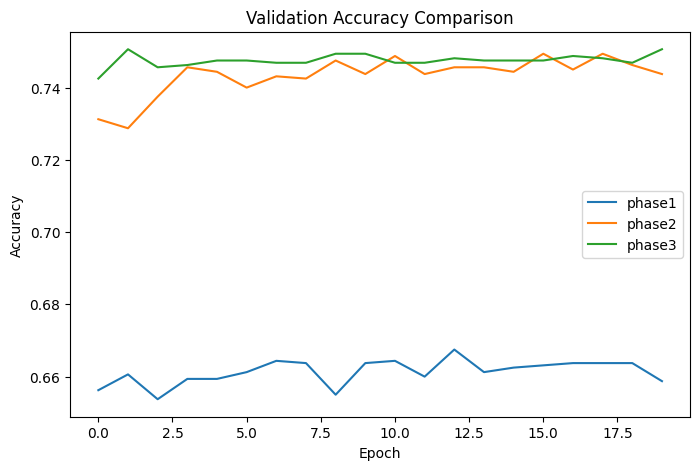

In [22]:
plt.figure(figsize=(8,5))
for phase in results:
    plt.plot(results[phase]["val_acc"], label=phase)

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [23]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import numpy as np

def evaluate(model, loader, device, model_path):
    model.load_state_dict(torch.load(model_path))
    model.to(device)
    model.eval()

    all_preds_binary = []
    all_labels_binary = []

    all_preds_multi = []
    all_labels_multi = []

    with torch.no_grad():
        for images, multi_labels, binary_labels in loader:
            images = images.to(device)
            multi_labels = multi_labels.to(device)
            binary_labels = binary_labels.to(device)

            multi_out, binary_out = model(images)

            # Binary
            preds_binary = torch.argmax(binary_out, dim=1)
            all_preds_binary.extend(preds_binary.cpu().numpy())
            all_labels_binary.extend(binary_labels.cpu().numpy())

            # Multi-class (convert multi-hot → class index)
            preds_multi = torch.argmax(multi_out, dim=1)
            labels_multi = torch.argmax(multi_labels, dim=1)

            all_preds_multi.extend(preds_multi.cpu().numpy())
            all_labels_multi.extend(labels_multi.cpu().numpy())

    # ===== BINARY =====
    acc_binary = (np.array(all_preds_binary) == np.array(all_labels_binary)).mean()
    f1_binary = f1_score(all_labels_binary, all_preds_binary)
    cm_binary = confusion_matrix(all_labels_binary, all_preds_binary)

    report_binary = classification_report(
        all_labels_binary,
        all_preds_binary,
        target_names=["No Threat", "Threat"]
    )

    # ===== MULTI =====
    acc_multi = (np.array(all_preds_multi) == np.array(all_labels_multi)).mean()
    f1_multi = f1_score(all_labels_multi, all_preds_multi, average='macro')
    cm_multi = confusion_matrix(all_labels_multi, all_preds_multi)

    report_multi = classification_report(all_labels_multi, all_preds_multi)

    return acc_binary, f1_binary, cm_binary, report_binary, \
           acc_multi, f1_multi, cm_multi, report_multi


In [24]:

acc_b, f1_b, cm_b, report_b, acc_m, f1_m, cm_m, report_m = evaluate(
    model, test_loader, device, f"{save_dir}/resnet.pth"
)

# Save confusion matrices
np.save(f"{save_dir}/confusion_matrix_binary.npy", cm_b)
np.save(f"{save_dir}/confusion_matrix_multi.npy", cm_m)

# Save results
with open(f"{save_dir}/results.txt", "w") as f:
    f.write("===== BINARY (Threat Detection) =====\n")
    f.write(f"Accuracy: {acc_b}\n")
    f.write(f"F1 Score: {f1_b}\n\n")
    f.write(report_b)

    f.write("\n\n===== MULTI-CLASS (Object Classification) =====\n")
    f.write(f"Accuracy: {acc_m}\n")
    f.write(f"F1 Score: {f1_m}\n\n")
    f.write(report_m)

print(report_b)
print(report_m)


              precision    recall  f1-score   support

   No Threat       0.97      1.00      0.98      1118
      Threat       0.99      0.92      0.96       482

    accuracy                           0.97      1600
   macro avg       0.98      0.96      0.97      1600
weighted avg       0.97      0.97      0.97      1600

              precision    recall  f1-score   support

           0       0.95      1.00      0.98      1118
           1       0.39      0.90      0.54        29
           2       0.21      0.17      0.19        35
           3       0.23      0.08      0.12        39
           4       0.12      0.03      0.05        32
           5       0.42      0.26      0.32        31
           6       0.29      0.55      0.38        33
           7       0.28      0.50      0.36        28
           8       0.23      0.22      0.22        32
           9       0.12      0.09      0.10        33
          10       0.33      0.10      0.16        29
          11       0.05 

# Model Saving and Reproducibility

To ensure reproducibility:
- The trained model weights are saved to a file
- The model can be reloaded without retraining

This allows:
- Reproducing results shown in the report
- Avoiding retraining from scratch


# Results and Observations

The model achieves strong performance on the **binary anomaly detection task**, with:
- Accuracy: 97%
- F1 Score: 0.97

This indicates that the model is highly effective at distinguishing between **threat and no-threat samples**, even under class imbalance.

From the training curves:
- Both training and validation loss decrease consistently
- The gap between training and validation loss remains small

This suggests:
- Stable convergence
- Minimal overfitting

For the **multi-class classification task**:
- Accuracy is relatively high (~76%)
- However, macro F1-score is low (~0.25)

This indicates that:
- The model performs well on dominant classes (e.g., class 0)
- Performance on minority classes remains inconsistent

Some minority classes show reasonable recall but low precision, indicating partial learning but poor discrimination.

Overall:
- Binary classification performs very well
- Multi-class performance improves with class weighting and phased training, but imbalance still affects minority classes

# Limitations and Failure Cases

The main limitation lies in the **multi-class classification performance under class imbalance**.

Key issues observed:
- The model is still biased toward dominant classes (e.g., class 0)
- Minority classes show low precision and inconsistent recall
- Macro F1-score remains low despite reasonable overall accuracy

Additionally:
- Some classes are over-predicted, leading to false positives
- The model struggles to clearly separate visually similar object categories

Failure cases include:
- Misclassification of rare object classes
- Confusion between minority categories
- Over-reliance on dominant class predictions

Future Possible improvements:
- Explore more advanced architectures or task-specific models like Resnet-34



In [ ]:
import time
while True:
    print("alive")
    time.sleep(600)

alive
alive
alive
alive
alive
alive
alive
alive
alive
alive
